In [1]:
from qiskit import QuantumCircuit , QuantumRegister,ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler, Session 
import numpy as np
from matplotlib import pyplot as plt

#TODO: enforce one classical data type
#TODO: make sure we select qubits with furthest connectivity 


class QuantumNeuralNetwork():

    """
    """

    def __init__(self,
                 layer_sizes:list,
                 activation_f:callable) -> "QuantumNeuralNetwork":
        
        self.layer_sizes = layer_sizes
        self.layer_n = len(layer_sizes)
        self.hidden_layer_n = len(layer_sizes) - 2
        self.b = [np.random.randn(layer_sizes[i]) for i in range(1, self.hidden_layer_n + 2)]
        self.W = [np.random.randn(layer_sizes[i], 
                                  layer_sizes[i - 1]) * np.sqrt(1 / layer_sizes[i - 1]) for i in range(1, self.hidden_layer_n + 2)]

        self.activation_f = activation_f
        self.service = None
        self.backend = None
        self.comms = None
        


    def establish_communication_with_ibm(self,
                                         simulation_mode=True,
                                         operational=True,
                                         optimization_level=3) -> None:

        try:
            # Initialize the runtime service (assumes you're logged in)
            self.service = QiskitRuntimeService()
        except Exception as e:
            raise ConnectionError("Failed to initialize QiskitRuntimeService.") from e

        try:
            # Choose a backend with session and measurement support
            self.backend = self.service.least_busy(simulator=simulation_mode,
                                                   operational=operational)
        except Exception as e:
            raise ConnectionError("Failed to select a backend.") from e

        try:
            # Generate the communication pass manager
            self.comms = generate_preset_pass_manager(backend=self.backend,
                                                      optimization_level=optimization_level)
        except Exception as e:
            raise RuntimeError("Failed to generate the communications pass manager.") from e



    def feedforward(self: "QuantumNeuralNetwork",input:np.ndarray[:]) -> np.ndarray[:]:

        zs = input
        for i in range(len(self.weights)-1):

            θ = np.pi/2*( 1- self.activation_f(self.weights[i]@zs))
            n_qbits = self.weights[i].shape[0]
            qr = QuantumRegister(n_qbits,name="qr")
            cr = ClassicalRegister(n_qbits,name="cr")
            qc = QuantumCircuit(qr, cr)
            for i,Θ in enumerate(θ):
                qc.ry(theta=Θ, qubit=i)
                qc.measure(qubit=i,cbit=i)
            isa_circuit = self.pm.run(qc)
            sampler = Sampler(mode=self.backend)
            job = sampler.run([isa_circuit], shots=1)
            result = job.result()
            counts = result[0].data.cr.get_counts()
            zs = np.fromiter((int(b) for b in next(iter(counts))), dtype=np.float16)

        output =  np.exp(self.weights[-1]@zs)/sum(np.exp(self.weights[-1]@ zs))
        return output
         

    def predict(self,
                Xs,
                n_samples)->list[np.ndarray[:]]:

        output = []
        for x in Xs:
            for _ in num_samples: 
            tmp = self.feedforward(x)
            output.append(tmp)

        return tmp 


In [ ]:
qnn = QuantumNeuralNetwork(layer_sizes=layer_sizes,
                     activation_f=htanh, 
                     quantumness=a)

qnn.establish_communication_with_ibm()
results = qnn.predict(Xs)
validation_rate = calculate_validation_rate(results,Ys)

NameError: name 'QuantumNeuralNetwork' is not defined

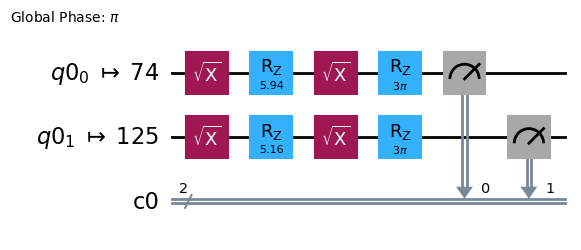

In [ ]:
σ = np.tanh
input= np.array([0,1,1,0])
layer_sizes = [4,2,2,3]

layer_sizes = layer_sizes
layer_n = len(layer_sizes)
hidden_layer_n = len(layer_sizes) - 2
b = [np.random.randn(layer_sizes[i]) for i in range(1, hidden_layer_n + 2)]
W = [np.random.randn(layer_sizes[i], 
                                  layer_sizes[i - 1]) * np.sqrt(1 / layer_sizes[i - 1]) for i in range(1, hidden_layer_n + 2)]

service = QiskitRuntimeService()  # Assumes you're logged in
# Choose a backend with session + measurement support
backend = service.least_busy(simulator=False, operational=True)

θ0 = np.pi/2*( 1- σ(W[0]@input))

qr = QuantumRegister(W[0].shape[0])
cr = ClassicalRegister(W[0].shape[0])
qc = QuantumCircuit(qr, cr)

for i,Θ in enumerate(θ0):
     qc.ry(theta=Θ, qubit=i)
     qc.measure(qubit=i,cbit=i)

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(qc)

isa_circuit.draw("mpl")

In [3]:
sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit], shots=1)
result = job.result()

In [24]:
counts = result[0].data.c0.get_counts()
arr = np.fromiter((int(b) for b in next(iter(counts))), dtype=np.float16)
arr
θ1 = np.pi/2*( 1- W[1] @ arr)

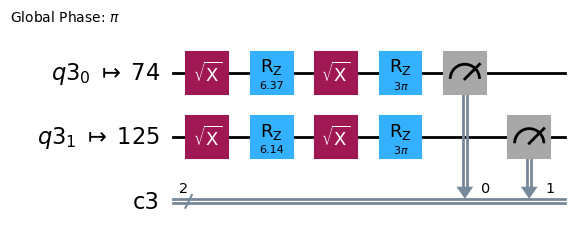

In [27]:
qr = QuantumRegister(W[1].shape[0])
cr = ClassicalRegister(W[1].shape[0])
qc = QuantumCircuit(qr, cr)

for i,Θ in enumerate(θ1):
     qc.ry(theta=Θ, qubit=i)
     qc.measure(qubit=i,cbit=i)

isa_circuit = pm.run(qc)

isa_circuit.draw("mpl")

In [28]:
sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit], shots=1)
result = job.result()

In [36]:
counts = result[0].data.c3.get_counts()
arr = np.fromiter((int(b) for b in next(iter(counts))), dtype=np.float16)
np.tanh(W[2] @ arr)

array([-0.200135  , -0.84789994, -0.56906341])

np.float64(-0.20013500237806772)

In [41]:
σ = np.tanh
input= np.array([0,1,1,0])
layer_sizes = [4,2,2,3]

layer_sizes = layer_sizes
layer_n = len(layer_sizes)
hidden_layer_n = len(layer_sizes) - 2
b = [np.random.randn(layer_sizes[i]) for i in range(1, hidden_layer_n + 2)]
W = [np.random.randn(layer_sizes[i], 
                                  layer_sizes[i - 1]) * np.sqrt(1 / layer_sizes[i - 1]) for i in range(1, hidden_layer_n + 2)]


service = QiskitRuntimeService()  # Assumes you're logged in
# Choose a backend with session + measurement support
backend = service.least_busy(simulator=False, operational=True)
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

zs = input

#TODO: make sure we select qubits with furthest connectivity 

for i in range(len(W)-1):

     θ = np.pi/2*( 1- np.tanh(W[i]@zs))
     n_qbits = W[i].shape[0]
     qr = QuantumRegister(n_qbits,name="qr")
     cr = ClassicalRegister(n_qbits,name="cr")
     qc = QuantumCircuit(qr, cr)

     for i,Θ in enumerate(θ):
          qc.ry(theta=Θ, qubit=i)
          qc.measure(qubit=i,cbit=i)

     isa_circuit = pm.run(qc)
     sampler = Sampler(mode=backend)
     job = sampler.run([isa_circuit], shots=1)
     result = job.result()
     counts = result[0].data.cr.get_counts()
     zs = np.fromiter((int(b) for b in next(iter(counts))), dtype=np.float16)


output =  np.exp(W[-1]@zs)/sum(np.exp(W[-1]@ zs))

In [43]:
output =  np.exp(W[-1]@zs)/sum(np.exp(W[-1]@ zs))

In [44]:
output

array([0.50166485, 0.17629738, 0.32203777])